<a href="https://colab.research.google.com/github/SAO-P/Pytorch-Exercise/blob/main/PyTorch3_1_nn_Linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

autograd

In [64]:
import torch

In [65]:
x=torch.tensor([1.],requires_grad=True)
print(x)

tensor([1.], requires_grad=True)


In [66]:
x=torch.tensor([1.])
print(x)
print(x.requires_grad)

tensor([1.])
False


In [67]:
x.requires_grad=True
print(x)
print(x.requires_grad)

tensor([1.], requires_grad=True)
True


기본은 False로 된다. 맨위에서 처럼 만들때 True로 하던가 나중에 바꿔주던가

In [68]:
x=torch.tensor([1.],requires_grad=True)
y=x**2
print(y)
print(x.grad)  #아무것도 안나올것

tensor([1.], grad_fn=<PowBackward0>)
None


Pow = Power => 거듭제곱

In [69]:
y.backward()   #미분하는함수
print(x.grad)  #y=x**2를 미분한 2x에 1을 대입한 gradient 값

tensor([2.])


In [70]:
x=torch.tensor([1.],requires_grad=True)
y=x**2
print(y)
#y.retain_grad() #이걸로 y.grad도 볼 수 있다.

z=3*y
print(z)

z.backward()
print(x.grad)
# print(y.grad) #이런 중간거는 안됨

tensor([1.], grad_fn=<PowBackward0>)
tensor([3.], grad_fn=<MulBackward0>)
tensor([6.])


Mul = Multiply => 곱

In [71]:
x=torch.tensor([1.],requires_grad=True)
y=torch.tensor([1.],requires_grad=True)
z=2*x**2 + y**2
print(z)  #AddBackward0 가 붙어있음
z.backward()
print(x.grad)
print(y.grad)

tensor([3.], grad_fn=<AddBackward0>)
tensor([4.])
tensor([2.])


In [72]:
x=torch.tensor([1.,2.,3.,],requires_grad=True)
y=torch.sum(x**2)  #x1**2 + x2**2 + x3**2
y.backward()

print(y)
print(x.grad)

tensor(14., grad_fn=<SumBackward0>)
tensor([2., 4., 6.])


In [73]:
x=torch.tensor([1.],requires_grad=True)
x.requires_grad=False
# transter learning 에서 필요
y=x**2
print(y)
#y.backward() #error!

tensor([1.])


In [74]:
x=torch.tensor([2.],requires_grad=True)
x2=x.detach() # detach는 requires_grad=False 인 새 텐서를 만드는 것

print(x)
y=x**2
print(y)

print(x2)
y2=x2**2
print(y2)


tensor([2.], requires_grad=True)
tensor([4.], grad_fn=<PowBackward0>)
tensor([2.])
tensor([4.])


x로 만든 것을 상수로 사용하고 싶을때, y.requires_grad=False 이런식으로는 안된다. 상수로서 카피해서 쓰기위해 detach를 사용

In [75]:
#많이 쓰이는 torch.no_grad
x=torch.tensor([1.],requires_grad=True)
# chain rule을 위해 계속 grad_fn을 업데이트 하는데, grad_fn을 잠시 계산하지 않고 싶을 때 사용
#모델 테스트 등에서는 불필요하게 메모리를 쓰지 않아도 되기 떄문.

with torch.no_grad():
    y = x**2
    print(x.requires_grad) #감싸도 여전히 requires_grad는 True!
    print(y) #with 내부에서 계산되는 것은 grad_fn이 붙지 않음

print(x.requires_grad)
# y.backward() #error!
y=x**2
print(y)


True
tensor([1.])
True
tensor([1.], grad_fn=<PowBackward0>)


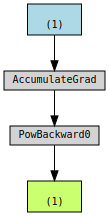

In [76]:
!pip install torchviz
from torchviz import make_dot
x=torch.tensor([1.],requires_grad=True)
#make_dot(x)
make_dot(x**2)


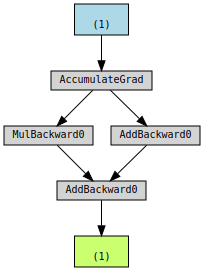

In [77]:
y=2*x
z=3+x
r=y+z
make_dot(r)

AccumulateGrad는 x로 여러가지 계산을 한것을 더해주기위해서 존재 (거꾸로 생각할때)

Linear(in_features=1, out_features=1, bias=True)
Parameter containing:
tensor([[0.9845]], requires_grad=True)
Parameter containing:
tensor([0.9160], requires_grad=True)
tensor([1.9006], grad_fn=<ViewBackward0>)
tensor([1.9006], grad_fn=<AddBackward0>)


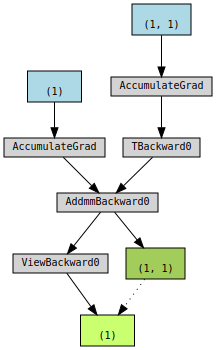

In [78]:
from torch import nn

x=torch.tensor([1.])
model=nn.Linear(1,1) # 입력노드 1 출력노드 1 인 layer
print(model)

print(model.weight) # 만들면서 initialize 함
print(model.bias)

y=model(x)
print(y)

y2 = x @ model.weight + model.bias #y와 동일하다. 식으로 나타내었을뿐.
print(y2)

make_dot(y)

TBackward0 <- Transpose

AddmmBackward0 <- add mm  행렬곱셈에 행렬 덧셈을 한것.

mm= matrix multiplication

In [79]:
fc1=nn.Linear(1,3) #fully-connected
fc2=nn.Linear(3,1)

print(fc1.weight) #3개
print(fc1.bias) #3개

print(fc2.weight) #3개
print(fc2.bias)  #1개

Parameter containing:
tensor([[-0.7587],
        [-0.4871],
        [-0.1970]], requires_grad=True)
Parameter containing:
tensor([0.7582, 0.1880, 0.5417], requires_grad=True)
Parameter containing:
tensor([[-0.5668,  0.3447,  0.2107]], requires_grad=True)
Parameter containing:
tensor([0.4964], requires_grad=True)


tensor([-0.0005, -0.2991,  0.3447], grad_fn=<ViewBackward0>)
tensor([0.4662], grad_fn=<ViewBackward0>)


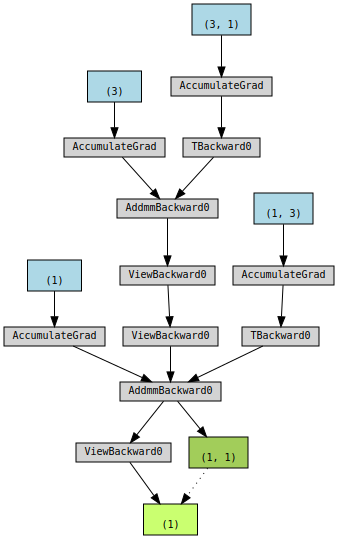

In [80]:
x=torch.tensor([1.])
x=fc1(x)
print(x)
y=fc2(x)
print(y)

make_dot(y)

tensor([0.4662], grad_fn=<AddBackward0>)


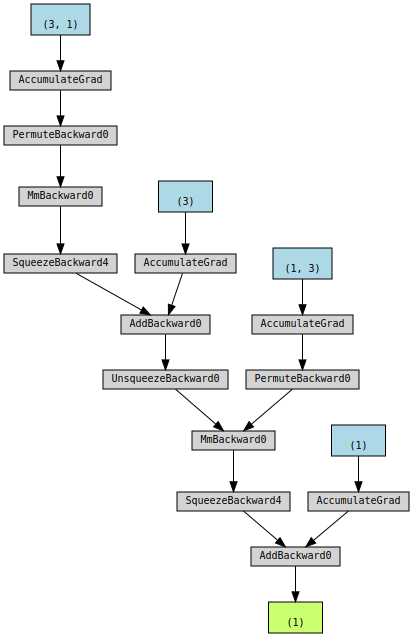

In [81]:
#위를 식으로 쓰면
x=torch.tensor([1.])
y2 = (x @ fc1.weight.T + fc1.bias) @ fc2.weight.T + fc2.bias
print(y2)
make_dot(y2)

tensor([1.8618, 0.3119])
tensor([-1.2798,  0.0353, -0.9702], grad_fn=<ViewBackward0>)


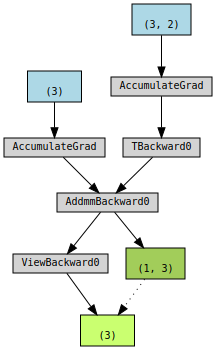

In [82]:
model = nn.Linear(2,3)
x = torch.randn(2)
print(x)
print(model(x))
#nn.Linear는 데이터의 shape의 마지막 차원이 '채'로 들어오길 기대한다.
#입력노드 하나가 곧 하나의 채널(피쳐) 값을 의미
make_dot(model(x))

In [83]:
model = nn.Linear(2,3) #2채널 3값
#따라서 데이터를 여러개 통과시키고 싶다면 개X채의 형태로 넣어야한다.
x=torch.randn(5,2) # 개X채 => 두개의 채널(피처; ex 키/몸무게) X 데이터수 ex 5명

print(x)
print(model(x))

x=torch.randn(4,5,2) #4개반 5명씩 2채널
print(model(x).shape)


tensor([[ 0.6882, -0.1717],
        [-0.7826, -0.1370],
        [-0.8682, -0.1901],
        [-1.0463,  0.5189],
        [-0.1937,  0.0429]])
tensor([[-0.1494,  0.1245,  0.5688],
        [-0.4185,  1.0942,  0.8710],
        [-0.4287,  1.1836,  0.9197],
        [-0.5308,  0.8798,  0.5578],
        [-0.3299,  0.5901,  0.6404]], grad_fn=<AddmmBackward0>)
torch.Size([4, 5, 3])


왜 weight 행렬에는 T를 취하나?

이것도 개X채 형태로 만들기위해서..

예를 들어 nn.Linear(2,3)이면 두 채널 값을 사용하는 세 '개'의 필터를 사용하는 것이기에

tensor([-0.7434], grad_fn=<ViewBackward0>)


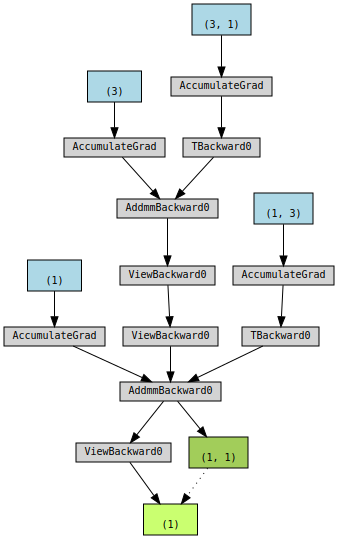

In [84]:
#nn.Sequential()
fc1=nn.Linear(1,3)
fc2=nn.Linear(3,1)

'''
x=torch.tensor([1.])
x=fc1(x)
print(x)
x=fc2(x)
print(x)
'''
model = nn.Sequential(fc1,fc2)
x=torch.tensor([1.])
print(model(x))

make_dot(model(x))

In [85]:
model = nn.Sequential(nn.Linear(2,5),
                      nn.Linear(5,10),
                      nn.Linear(10,3)) #(in채널,out채널) 이니까 연결되는 부분이 같아야함
x=torch.rand(5,2)
print(x)
print(model(x))

tensor([[0.7956, 0.5969],
        [0.6906, 0.5640],
        [0.1268, 0.0115],
        [0.4941, 0.9006],
        [0.4161, 0.8842]])
tensor([[0.3345, 0.3193, 0.3368],
        [0.2967, 0.3141, 0.3641],
        [0.0659, 0.2583, 0.4426],
        [0.2551, 0.3347, 0.4874],
        [0.2276, 0.3315, 0.5092]], grad_fn=<AddmmBackward0>)


tensor([[0.5149, 0.5036, 0.4708],
        [0.5146, 0.5033, 0.4712],
        [0.5151, 0.5042, 0.4705],
        [0.5150, 0.5030, 0.4707],
        [0.5142, 0.5039, 0.4716]], grad_fn=<SigmoidBackward0>)


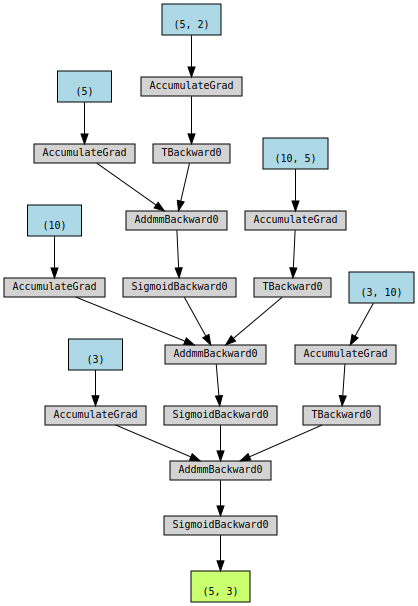

In [86]:
#보통은 클래스를 가지고 모델의 정의를 많이한다.

class MyModel(nn.Module):  #MyModel은 다른 이름으로 맘대로 가
  def __init__(self):
    super().__init__()

    self.fc1 = nn.Linear(2,5)
    self.fc2 = nn.Linear(5,10)
    self.fc3 = nn.Linear(10,3)
    self.act = nn.Sigmoid()

  def forward(self,x):  #foward <-그대로써야함
    x=self.fc1(x)
    x=self.act(x)
    x=self.fc2(x)
    x=self.act(x)
    x=self.fc3(x)
    x=self.act(x)
    return x

model = MyModel()
x = torch.rand(5,2)
y = model(x)  # model.forward(x) 와 동일 (nn.Module의 __call__에서 forward를 통과시킴 = forward를 자식 클래스에서 오버라이딩하는 것) (__call__은 인스턴스()로 호출하는 메소드)
print(y)

make_dot(y)




tensor([[0.6176, 0.5651, 0.5807],
        [0.6185, 0.5616, 0.5767],
        [0.6189, 0.5637, 0.5799],
        [0.6188, 0.5651, 0.5818],
        [0.6192, 0.5638, 0.5802]], grad_fn=<SigmoidBackward0>)


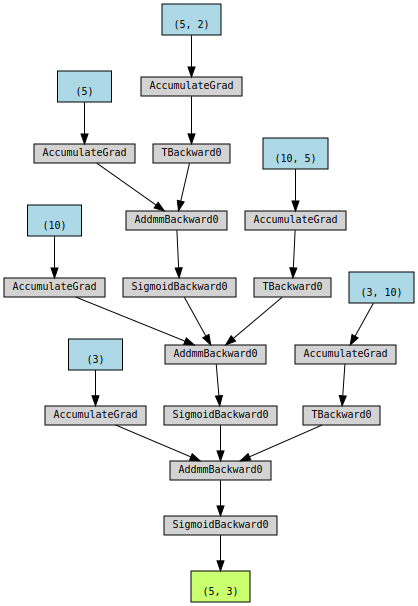

In [93]:
class MyModel2(nn.Module):
  def __init__(self):
      super().__init__()

      self.linear = nn.Sequential(nn.Linear(2,5),
                                  nn.Sigmoid(),
                                  nn.Linear(5,10),
                                  nn.Sigmoid(),
                                  nn.Linear(10,3),
                                  nn.Sigmoid())

  def forward(self, x):
      x = self.linear(x)
      return x

model2 = MyModel2()
x = torch.randn(5,2)
y = model2(x)
print(y)

make_dot(y)

In [94]:
print(model2)
print(model2.linear[0].weight)
print(model2.linear[-2].bias)
#Sequential 로 만들었을땐 인덱싱 가능 시그모이드도 인덱스니까 주의)

MyModel2(
  (linear): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=5, out_features=10, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=10, out_features=3, bias=True)
    (5): Sigmoid()
  )
)
Parameter containing:
tensor([[-0.6625, -0.4417],
        [-0.3186,  0.5860],
        [ 0.0690, -0.1077],
        [ 0.0190,  0.6386],
        [-0.3184, -0.1166]], requires_grad=True)
Parameter containing:
tensor([ 0.2362,  0.0248, -0.0306], requires_grad=True)
